In [1]:
!pip install -q giotto-tda
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 63.8 MB/s eta 0:00:00


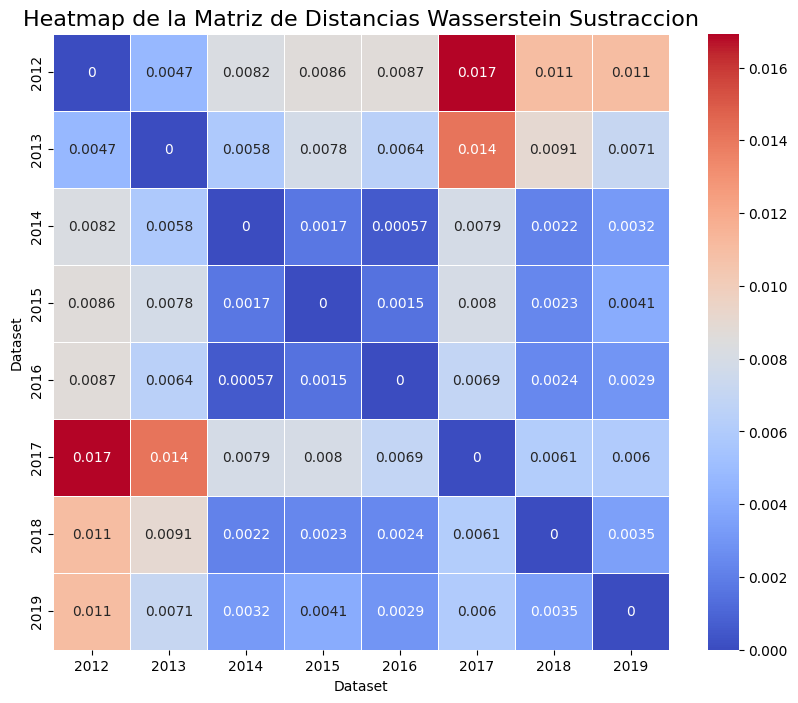

<function matplotlib.pyplot.ylabel(ylabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

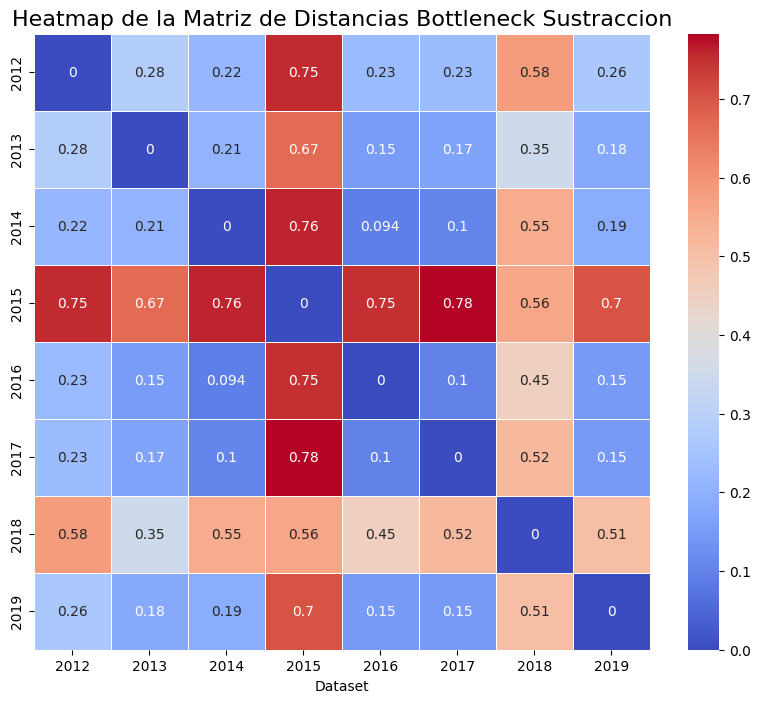

In [2]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Constante aleatoria para la resta en la distancia Wasserstein
distancia_aleatoria_wasserstein = 0.001932205797002203

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path):
    df = pd.read_csv(file_path)
    data = df[['crime_lon', 'crime_lat']].values
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    max_len = max(len(diag1), len(diag2))
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Rellenar con NaN para igualar las longitudes de los vectores
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular las distancias Wasserstein para nacimientos y muertes
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    return distance_births + distance_deaths

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Función para calcular las dos matrices de distancias
def calculate_both_distance_matrices(diagrams):
    num_diagrams = len(diagrams)
    wasserstein_matrix = np.zeros((num_diagrams, num_diagrams))
    bottleneck_matrix = np.zeros((num_diagrams, num_diagrams))

    for i in range(num_diagrams):
        for j in range(i + 1, num_diagrams):
            # Calcular distancia de Wasserstein
            wasserstein_dist = wasserstein_distance_between_diagrams(diagrams[i], diagrams[j])
            wasserstein_matrix[i, j] = wasserstein_dist
            wasserstein_matrix[j, i] = wasserstein_dist

            # Calcular distancia Bottleneck
            bottleneck_dist = bottleneck_distance_between_diagrams(diagrams[i], diagrams[j])
            bottleneck_matrix[i, j] = bottleneck_dist
            bottleneck_matrix[j, i] = bottleneck_dist

    return wasserstein_matrix, bottleneck_matrix

# Archivos CSV
files = [
    'Valencia_2012_Sustraccion_sampled.csv',
    'Valencia_2013_Sustraccion_sampled.csv',
    'Valencia_2014_Sustraccion_sampled.csv',
    'Valencia_2015_Sustraccion_sampled.csv',
    'Valencia_2016_Sustraccion_sampled.csv',
    'Valencia_2017_Sustraccion_sampled.csv',
    'Valencia_2018_Sustraccion_sampled.csv',
    'Valencia_2019_Sustraccion_sampled.csv',

]

# Calcular diagramas de persistencia una sola vez
diagrams = [calculate_persistence_diagram(file) for file in files]

# Calcular ambas matrices de distancias
wasserstein_matrix, bottleneck_matrix = calculate_both_distance_matrices(diagrams)

# Ajustar la matriz de distancias Wasserstein restando la constante aleatoria (excepto en la diagonal)
wasserstein_matrix_adjusted = wasserstein_matrix.copy()
np.fill_diagonal(wasserstein_matrix_adjusted, 0)
wasserstein_matrix_adjusted = np.where(np.eye(wasserstein_matrix.shape[0]), 0, wasserstein_matrix_adjusted - distancia_aleatoria_wasserstein)

# Nombres de los datasets
csv_names = ['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Crear un heatmap para la distancia Wasserstein ajustada
plt.figure(figsize=(10, 8))
sns.heatmap(wasserstein_matrix_adjusted, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein Sustraccion', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap ajustado de Wasserstein
plt.show()

# Crear un heatmap para la distancia Bottleneck sin ajuste
plt.figure(figsize=(10, 8))
sns.heatmap(bottleneck_matrix, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck Sustraccion', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel

